# Notebook for experimenting different toy stellar wind models for modeling X-Ray Light Curves

In [11]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
from xrb_lightcurve import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## ObsID 15803 in Soft band (0.5-2.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft/single
Removed 131 zero/NaN flux data points (1367 remaining)


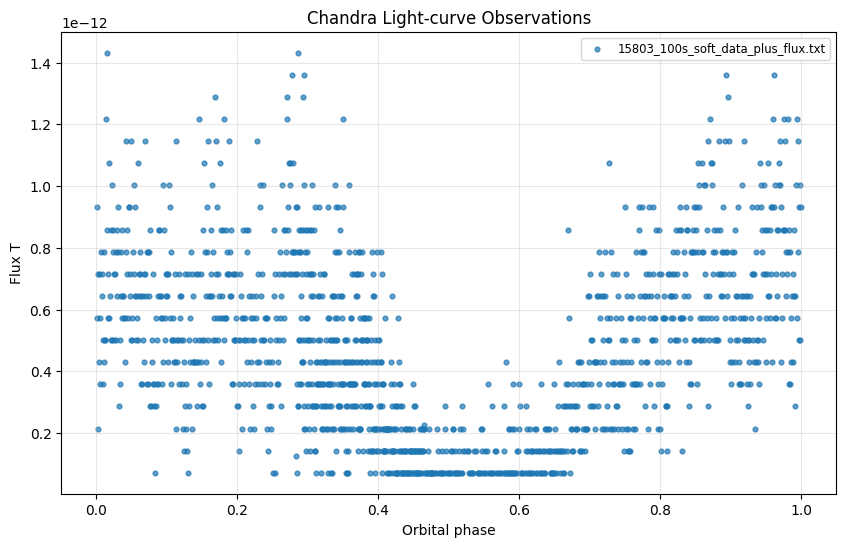

In [2]:
# Plot soft band LC
obs_column = "flux_t"
time_column = "t_raw"
data = load_data("./data/IC_10_X1_LC_CIAO/soft/single", obs_column = obs_column, time_column = time_column)
n_before = len(data)
data_df = data[(data['rate'] != 0) & (data['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(data_df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(data_df)} remaining)")
plot_phase(data_df, None, obs_column_name = obs_column)

### Smoothly Broken Power-law wind

In [3]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate --wind-model smooth_pl \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_soft.csv \
--output ./analyses/sim_flux_tbabs_15803_smooth_pl_soft.csv \
--i0 22.625344 --lam 0.533545 --r 0.074665 --R 2.620185 --d1 1.909942 --d2 1.907222 --dth 2.0 --converge-rmax")

/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:916: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.074665 solar radii
  R (companion radius): 2.620185 solar radii
  d1 (emitter separation): 1.909942 solar radii
  d2 (companion separation): 1.907222 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 22.625344 degrees
  dth (orbital increment): 2.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.5
  Rmax (LOS cutoff): 7.634328
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_soft.csv
  flux_type: erg
  lam: 0.533545
  wind_model: smooth_pl
  wind_params: {'Rb': 5.0, 'p': 4.0, 'Delta': 2.0}
  Output file: ./analyses/sim_flux_tbabs_15803_smooth_pl_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_tbabs_15803_smooth_pl_soft.csv
Total data points: 180
Phase range: -90.00 to 268.00 degrees


0

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 3.389


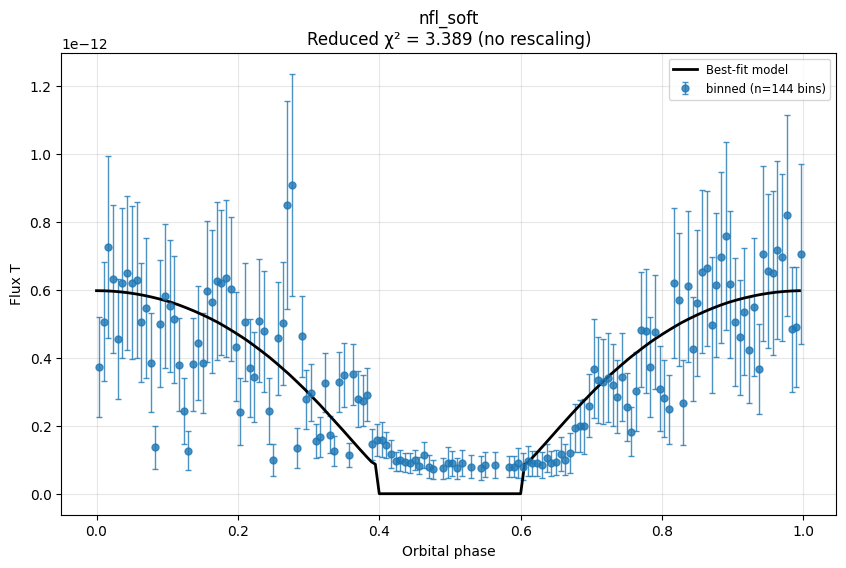

In [9]:
# Fit smooth_pl model to data
sim_df = pd.read_csv("./analyses/sim_flux_tbabs_15803_smooth_pl_soft.csv")
sim_columns = detect_flux_columns(sim_df)
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

Detected energy bands in CSV: soft
Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 3.352


/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:916: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


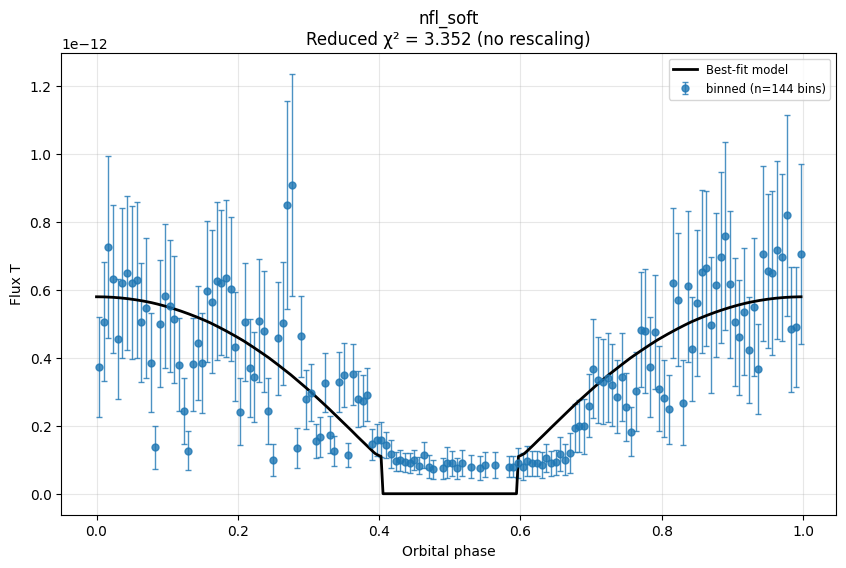

In [38]:
# Trying different shapes of smooth powerlaw
wind_params = {"Rb": 7, "p": 3, "Delta": 1}
sim_df = simulate_lightcurve(
        r=0.074665,
        R=2.620185,
        d1=2.23,
        d2=1.70,
        gma0=-90,
        i0=22,
        dth=1,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_soft.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="smooth_pl",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

### Velocity based density model

In [5]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate --wind-model beta_law \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_soft.csv \
--output ./analyses/sim_flux_tbabs_15803_beta_law_soft.csv \
--i0 22.625344 --lam 0.533545 --r 0.074665 --R 2.620185 --d1 1.909942 --d2 1.907222 --dth 2.0 --converge-rmax")

/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:916: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.074665 solar radii
  R (companion radius): 2.620185 solar radii
  d1 (emitter separation): 1.909942 solar radii
  d2 (companion separation): 1.907222 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 22.625344 degrees
  dth (orbital increment): 2.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.5
  Rmax (LOS cutoff): 7.634328
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_soft.csv
  flux_type: erg
  lam: 0.533545
  wind_model: beta_law
  wind_params: {'R_star': 2.620185, 'beta': 1.0, 'H': 1.0}
  Output file: ./analyses/sim_flux_tbabs_15803_beta_law_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_tbabs_15803_beta_law_soft.csv
Total data points: 180
Phase range: -90.00 to 268.00 degrees


0

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)

Fitting column: nfl_soft
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 68.771


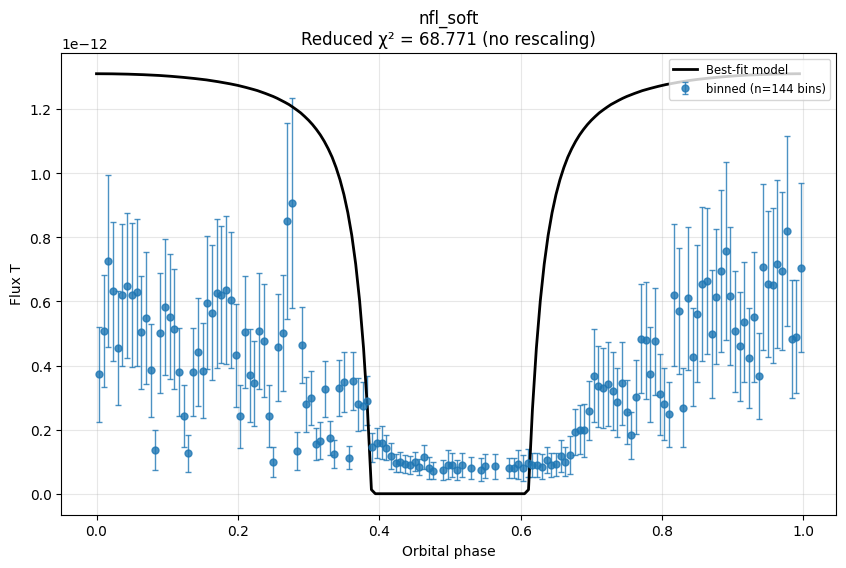

In [7]:
# Fit beta_law model to data
sim_df = pd.read_csv("./analyses/sim_flux_tbabs_15803_beta_law_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
no_phase_bin = False
if not no_phase_bin:
        df = phase_bin_data(
            df,
            n_bins=150,
            min_points_per_bin=5,
            rate_column='rate',
            error_column='error',
            verbose=True
        )
        is_binned = True
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=is_binned)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

### Inner confinement or compression model

In [8]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate --wind-model confinement \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_soft.csv \
--output ./analyses/sim_flux_tbabs_15803_confinement_soft.csv \
--i0 22.625344 --lam 0.533545 --r 0.074665 --R 2.620185 --d1 1.909942 --d2 1.907222 --dth 2.0 --converge-rmax")

/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:916: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.074665 solar radii
  R (companion radius): 2.620185 solar radii
  d1 (emitter separation): 1.909942 solar radii
  d2 (companion separation): 1.907222 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 22.625344 degrees
  dth (orbital increment): 2.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.5
  Rmax (LOS cutoff): 7.634328
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_soft.csv
  flux_type: erg
  lam: 0.533545
  wind_model: confinement
  wind_params: {'R_star': 2.620185, 'fconf': 10.0, 'ell': 0.5}
  Output file: ./analyses/sim_flux_tbabs_15803_confinement_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_tbabs_15803_confinement_soft.csv
Total data points: 180
Phase range: -90.00 to 268.00 degrees


0

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)

Fitting column: nfl_soft
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.733


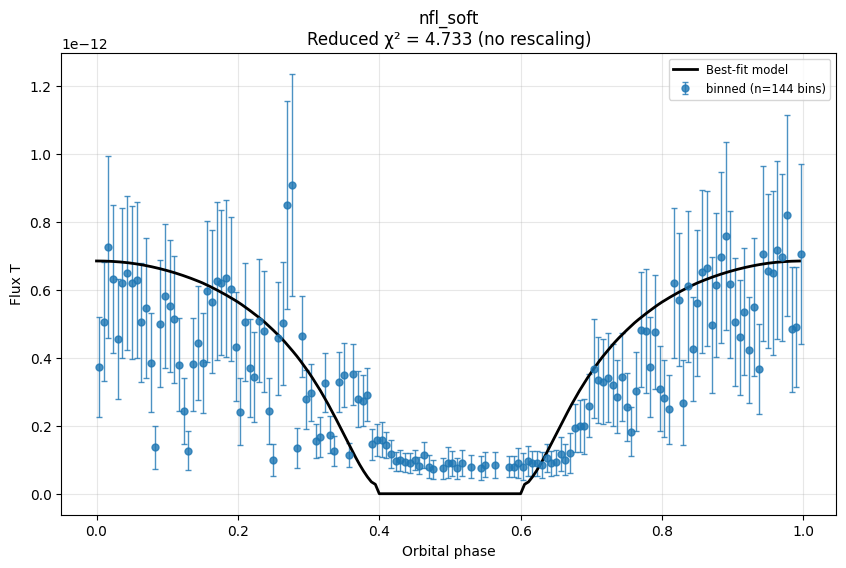

In [10]:
# Fit conf model to data
sim_df = pd.read_csv("./analyses/sim_flux_tbabs_15803_confinement_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
no_phase_bin = False
if not no_phase_bin:
        df = phase_bin_data(
            df,
            n_bins=150,
            min_points_per_bin=5,
            rate_column='rate',
            error_column='error',
            verbose=True
        )
        is_binned = True
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=is_binned)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)